# ResNet-50 — Klasifikasi Penyakit Tanaman + Kelas *Unknown* (13 kelas)
**Model:** `microsoft/resnet-50` (HuggingFace) · **Platform:** Kaggle (GPU)
**Kelas:** 12 penyakit (apel, anggur, jagung, tomat) + 1 kelas **unknown** = **13 kelas**

Notebook ini melatih **4 rasio split sekaligus** dalam satu run: `SPLIT_80_10_10`, `SPLIT_70_15_15`, `SPLIT_60_20_20`, `SPLIT_50_25_25`.
Setiap split menghasilkan model, metrik, dan grafiknya sendiri di `/kaggle/working/`.

> **Struktur dataset bersarang** (`<tanaman>/<penyakit>/` + `unknown/`) dibaca oleh *loader* khusus di Cell 4 sehingga tetap menjadi **13 kelas** (label penyakit diberi awalan tanaman, mis. `apel__apple_scab`; kelas non-target = `unknown`).

## Cell 1 — Persiapan (library & cek GPU)
Aktifkan **GPU** (Settings ▸ Accelerator ▸ GPU T4/P100) dan **Internet ON** (diperlukan untuk mengunduh bobot pra-latih `microsoft/resnet-50`).

In [1]:
# Cell 1: install & import
import subprocess, sys
try:
    import transformers  # biasanya sudah ada di Kaggle
except Exception:
    subprocess.run([sys.executable,"-m","pip","install","-q","transformers","accelerate"])

import os, json, time, random
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import ResNetForImageClassification
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch      :', torch.__version__)
print('Device       :', DEVICE)
if DEVICE.type=='cuda':
    print('GPU          :', torch.cuda.get_device_name(0))
    print('VRAM (GB)    : %.1f' % (torch.cuda.get_device_properties(0).total_memory/1e9))

PyTorch      : 2.10.0+cu128
Device       : cuda
GPU          : Tesla T4
VRAM (GB)    : 15.6


## Cell 2 — Konfigurasi global

In [2]:
# Cell 2: konfigurasi
MODEL_NAME  = 'microsoft/resnet-50'
NUM_CLASSES = 13     # 12 penyakit + unknown
BATCH_SIZE  = 32
NUM_EPOCHS  = 30
LR          = 1e-3
LR_PATIENCE = 3
ES_PATIENCE = 7
IMAGE_SIZE  = 224
SEED        = 42

# Ambang confidence untuk pendekatan GABUNGAN (kelas unknown eksplisit + threshold).
# Saat inferensi/evaluasi: bila probabilitas tertinggi < UNKNOWN_THRESHOLD -> diprediksi 'unknown'.
UNKNOWN_THRESHOLD = 0.70

OUT_ROOT = '/kaggle/working'

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type=='cuda': torch.cuda.manual_seed_all(SEED)

# ── Deteksi otomatis folder split di /kaggle/input ─────────────────
# Mendukung dua cara upload:
#  (a) 1 dataset berisi 4 folder split (masing-masing punya train/val/test), atau
#  (b) 4 dataset terpisah (tiap dataset punya train/val/test).
def find_split_roots(base='/kaggle/input'):
    roots=[]
    for dp, dn, _ in os.walk(base):
        if {'train','val','test'}.issubset(set(dn)):
            roots.append(dp)
    return sorted(roots)

SPLIT_ROOTS = find_split_roots()
print('Split terdeteksi:')
for r in SPLIT_ROOTS:
    print('  -', os.path.basename(r), '->', r)
assert SPLIT_ROOTS, 'Tidak menemukan folder berisi train/val/test di /kaggle/input. Pastikan dataset sudah di-Add.'

# Pilih split yang ingin dilatih (default: semua yang terdeteksi).
# Untuk hemat waktu, bisa diisi sebagian, mis. ['SPLIT_80_10_10'].
SPLITS_TO_RUN = [os.path.basename(r) for r in SPLIT_ROOTS]
print('\nAkan dilatih:', SPLITS_TO_RUN)

Split terdeteksi:
  - SPLIT_50_25_25 -> /kaggle/input/datasets/tannyaprlni/split-50-25-25/SPLIT_50_25_25
  - SPLIT_60_20_20 -> /kaggle/input/datasets/tannyaprlni/split-60-20-20/SPLIT_60_20_20
  - SPLIT_70_15_15 -> /kaggle/input/datasets/tannyaprlni/split-70-15-15/SPLIT_70_15_15
  - SPLIT_80_10_10 -> /kaggle/input/datasets/tannyaprlni/split-80-10-10/SPLIT_80_10_10

Akan dilatih: ['SPLIT_50_25_25', 'SPLIT_60_20_20', 'SPLIT_70_15_15', 'SPLIT_80_10_10']


## Cell 3 — Loader khusus (struktur bersarang → 13 kelas)
`ImageFolder` biasa hanya membaca 1 level (akan salah menjadi 5 kelas). `NestedLeafDataset` di bawah membaca folder tingkat-daun sebagai kelas: penyakit → `"<tanaman>__<penyakit>"`, dan `unknown/` → `"unknown"`.

In [3]:
# Cell 3: Dataset & transform
MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
train_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMAGE_SIZE,IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN,STD),
])

def _label_from_relpath(rel):
    parts = rel.replace('\\','/').split('/')
    if parts[0].lower()=='unknown':
        return 'unknown'
    # parts = [tanaman, penyakit]
    return parts[0] + '__' + parts[-1]

class NestedLeafDataset(Dataset):
    """Baca gambar dari struktur <tanaman>/<penyakit>/ (+ unknown/) sebagai 13 kelas."""
    def __init__(self, root, transform, class_to_idx=None):
        self.transform=transform
        samples=[]; labels=set()
        for dp,_,fns in os.walk(root):
            imgs=[f for f in fns if f.lower().endswith(('.jpg','.jpeg','.png'))]
            if not imgs: continue
            rel=os.path.relpath(dp,root)
            lbl=_label_from_relpath(rel)
            labels.add(lbl)
            for f in imgs: samples.append((os.path.join(dp,f), lbl))
        if class_to_idx is None:
            self.classes=sorted(labels)
            self.class_to_idx={c:i for i,c in enumerate(self.classes)}
        else:
            self.class_to_idx=class_to_idx
            self.classes=[c for c,_ in sorted(class_to_idx.items(), key=lambda x:x[1])]
        self.samples=[(p, self.class_to_idx[l]) for p,l in samples]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        p,y=self.samples[i]
        img=Image.open(p).convert('RGB')
        return self.transform(img), y

def build_loaders(root):
    tr=NestedLeafDataset(os.path.join(root,'train'), train_tf)
    c2i=tr.class_to_idx
    va=NestedLeafDataset(os.path.join(root,'val'),  eval_tf, c2i)
    te=NestedLeafDataset(os.path.join(root,'test'), eval_tf, c2i)
    assert len(tr.classes)==NUM_CLASSES, f'Dapat {len(tr.classes)} kelas: {tr.classes}'
    tl=DataLoader(tr,batch_size=BATCH_SIZE,shuffle=True, num_workers=2,pin_memory=True)
    vl=DataLoader(va,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
    xl=DataLoader(te,batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
    return tr,va,te,tl,vl,xl

## Cell 4 — Fungsi training + evaluasi untuk satu split

In [4]:
# Cell 4: EarlyStopping + train/eval satu split
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4, save_path=None):
        self.patience=patience; self.min_delta=min_delta; self.save_path=save_path
        self.best=float('inf'); self.counter=0
    def __call__(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best=val_loss; self.counter=0
            if self.save_path:
                torch.save(model.state_dict(), self.save_path)
            return False
        self.counter+=1
        return self.counter>=self.patience

def train_one_split(name, root):
    print('\n'+'='*70); print('  SPLIT:', name); print('='*70)
    save_dir=os.path.join(OUT_ROOT, 'MODEL_'+name); os.makedirs(save_dir, exist_ok=True)
    tr,va,te,tl,vl,xl = build_loaders(root)
    CLASSES=tr.classes
    print('Jumlah kelas :', len(CLASSES))
    print('Train/Val/Test:', len(tr), '/', len(va), '/', len(te))

    model=ResNetForImageClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True).to(DEVICE)
    criterion=nn.CrossEntropyLoss()
    optimizer=torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                         patience=LR_PATIENCE, factor=0.5)
    best_path=os.path.join(save_dir,'resnet50_best.pt')
    stopper=EarlyStopping(patience=ES_PATIENCE, save_path=best_path)
    history={'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}

    for epoch in range(1, NUM_EPOCHS+1):
        model.train(); tl_loss=0.0; tl_correct=0
        for x,y in tqdm(tl, desc=f'[{name}] Epoch {epoch} train', leave=False):
            x,y=x.to(DEVICE),y.to(DEVICE)
            optimizer.zero_grad()
            out=model(pixel_values=x).logits
            loss=criterion(out,y); loss.backward(); optimizer.step()
            tl_loss+=loss.item()*x.size(0); tl_correct+=(out.argmax(1)==y).sum().item()
        tl_loss/=len(tr); tr_acc=tl_correct/len(tr)

        model.eval(); vloss=0.0; vcorrect=0
        with torch.no_grad():
            for x,y in vl:
                x,y=x.to(DEVICE),y.to(DEVICE)
                out=model(pixel_values=x).logits
                vloss+=criterion(out,y).item()*x.size(0); vcorrect+=(out.argmax(1)==y).sum().item()
        vloss/=len(va); v_acc=vcorrect/len(va)
        history['train_loss'].append(tl_loss); history['val_loss'].append(vloss)
        history['train_acc'].append(tr_acc);   history['val_acc'].append(v_acc)
        scheduler.step(vloss)
        lr_now=optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:02d} | train_loss {tl_loss:.4f} acc {tr_acc:.4f} | '
              f'val_loss {vloss:.4f} acc {v_acc:.4f} | lr {lr_now:.2e}')
        if stopper(vloss, model):
            print(f'  Early stopping di epoch {epoch} (best val_loss={stopper.best:.4f})'); break

    # ── plot history ──
    ep=range(1,len(history['train_loss'])+1)
    fig,ax=plt.subplots(1,2,figsize=(14,5))
    ax[0].plot(ep,history['train_loss'],'b-o',ms=3,label='train'); ax[0].plot(ep,history['val_loss'],'r-o',ms=3,label='val')
    ax[0].set_title(f'Loss — {name}'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(ep,history['train_acc'],'b-o',ms=3,label='train'); ax[1].plot(ep,history['val_acc'],'r-o',ms=3,label='val')
    ax[1].set_title(f'Accuracy — {name}'); ax[1].set_ylim(0,1); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(os.path.join(save_dir,'training_history.png'),dpi=130,bbox_inches='tight'); plt.show()

    # ── evaluasi test (best model) ──
    model.load_state_dict(torch.load(best_path, map_location=DEVICE)); model.eval()
    all_logits=[]; all_labels=[]
    with torch.no_grad():
        for x,y in tqdm(xl, desc=f'[{name}] test', leave=False):
            out=model(pixel_values=x.to(DEVICE)).logits
            all_logits.append(out.cpu()); all_labels.append(y)
    logits=torch.cat(all_logits); labels=torch.cat(all_labels).numpy()
    probs=torch.softmax(logits,1).numpy(); preds=probs.argmax(1)

    acc=accuracy_score(labels,preds); prec=precision_score(labels,preds,average='weighted',zero_division=0)
    rec=recall_score(labels,preds,average='weighted',zero_division=0); f1=f1_score(labels,preds,average='weighted',zero_division=0)
    rep=classification_report(labels,preds,target_names=CLASSES,zero_division=0)
    print(f'\n[{name}] TEST  acc {acc:.4f} | prec {prec:.4f} | rec {rec:.4f} | f1 {f1:.4f}')
    print(rep)

    # ── evaluasi pendekatan GABUNGAN (threshold -> unknown) ──
    unk=CLASSES.index('unknown')
    preds_thr=preds.copy()
    preds_thr[probs.max(1) < UNKNOWN_THRESHOLD] = unk
    acc_thr=accuracy_score(labels,preds_thr); f1_thr=f1_score(labels,preds_thr,average='weighted',zero_division=0)
    rep_thr=classification_report(labels,preds_thr,target_names=CLASSES,zero_division=0)
    print(f'[{name}] + threshold {UNKNOWN_THRESHOLD}:  acc {acc_thr:.4f} | f1 {f1_thr:.4f}')

    # simpan laporan lengkap ke file (agar ikut terunduh)
    with open(os.path.join(save_dir,'classification_report.txt'),'w') as fr:
        fr.write(f'SPLIT: {name}\n')
        fr.write(f'TEST  acc {acc:.4f} | prec {prec:.4f} | rec {rec:.4f} | f1 {f1:.4f}\n\n')
        fr.write('Classification report (argmax):\n'+rep+'\n\n')
        fr.write(f'Dengan threshold {UNKNOWN_THRESHOLD} -> unknown:  acc {acc_thr:.4f} | f1 {f1_thr:.4f}\n\n')
        fr.write('Classification report (dengan threshold):\n'+rep_thr+'\n')

    # ── confusion matrix ──
    cm=confusion_matrix(labels,preds)
    plt.figure(figsize=(12,10))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASSES,yticklabels=CLASSES)
    plt.title(f'Confusion Matrix — {name}'); plt.xlabel('Predicted'); plt.ylabel('True')
    plt.xticks(rotation=90); plt.yticks(rotation=0)
    plt.tight_layout(); plt.savefig(os.path.join(save_dir,'confusion_matrix.png'),dpi=130,bbox_inches='tight'); plt.show()

    # ── simpan model & metrik ──
    torch.save({'model_state_dict':model.state_dict(),'class_to_idx':tr.class_to_idx,
                'classes':CLASSES,'model_name':MODEL_NAME,'num_classes':NUM_CLASSES,
                'image_size':IMAGE_SIZE,'unknown_threshold':UNKNOWN_THRESHOLD},
               os.path.join(save_dir,'resnet50_final.pt'))
    metrics={'split':name,'test_accuracy':round(float(acc),4),'test_precision':round(float(prec),4),
             'test_recall':round(float(rec),4),'test_f1':round(float(f1),4),
             'test_accuracy_threshold':round(float(acc_thr),4),'test_f1_threshold':round(float(f1_thr),4),
             'epochs_trained':len(history['train_loss']),'best_val_loss':round(float(stopper.best),4)}
    json.dump(metrics, open(os.path.join(save_dir,'metrics.json'),'w'), indent=2)
    json.dump(history, open(os.path.join(save_dir,'history.json'),'w'), indent=2)
    np.savetxt(os.path.join(save_dir,'confusion_matrix.csv'), cm, fmt='%d', delimiter=',')
    print(f'[{name}] Tersimpan di {save_dir}')
    return metrics

## Cell 5 — Jalankan semua split
Gunakan **Save Version ▸ Save & Run All (Commit)** agar keempat training berjalan sampai selesai (bisa beberapa jam; *EarlyStopping* mempercepat). Hasil tiap split ada di `/kaggle/working/MODEL_<split>/`.


  SPLIT: SPLIT_50_25_25
Jumlah kelas : 13
Train/Val/Test: 1867 / 934 / 934


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                           
--------------------+----------+-------------------------------------------------------------------------------------------
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([13])            
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([13, 2048])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


...

Epoch 23 | train_loss 0.0103 acc 0.9963 | val_loss 0.0926 acc 0.9786 | lr 1.25e-04


[SPLIT_50_25_25] Epoch 24 train:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 24 | train_loss 0.0097 acc 0.9968 | val_loss 0.0949 acc 0.9818 | lr 1.25e-04


[SPLIT_50_25_25] Epoch 25 train:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 25 | train_loss 0.0080 acc 0.9989 | val_loss 0.1074 acc 0.9754 | lr 1.25e-04
  Early stopping di epoch 25 (best val_loss=0.0786)


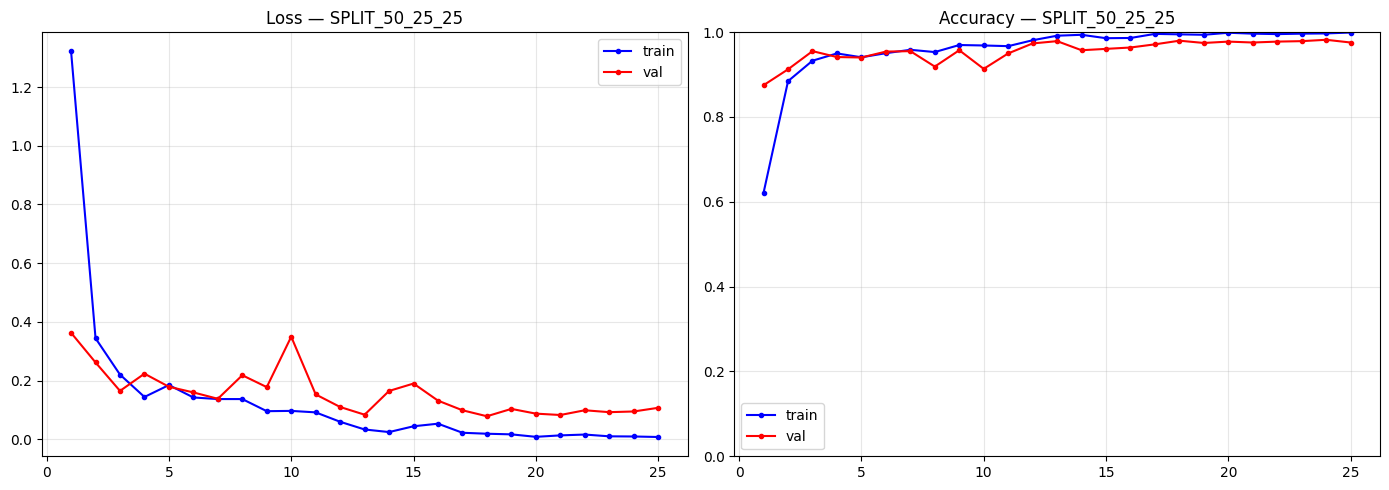

[SPLIT_50_25_25] test:   0%|          | 0/30 [00:00<?, ?it/s]


[SPLIT_50_25_25] TEST  acc 0.9679 | prec 0.9693 | rec 0.9679 | f1 0.9679
                                               precision    recall  f1-score   support

                             apel__apple_scab       1.00      1.00      1.00        68
                              apel__black_rot       1.00      1.00      1.00        68
                       apel__cedar_apple_rust       0.96      1.00      0.98        64
                       grape__grape_black_rot       0.96      0.99      0.97        69
              grape__grape_esca_black_measles       1.00      0.96      0.98        68
grape__grape_leaf_blight_isariopsis_leaf_spot       1.00      1.00      1.00        68
                           jagung__cercospora       0.91      0.93      0.92        68
                          jagung__common_rust       1.00      0.94      0.97        69
                          jagung__leaf_blight       0.89      0.94      0.91        68
                        tomat__bacterial_spot       1.0

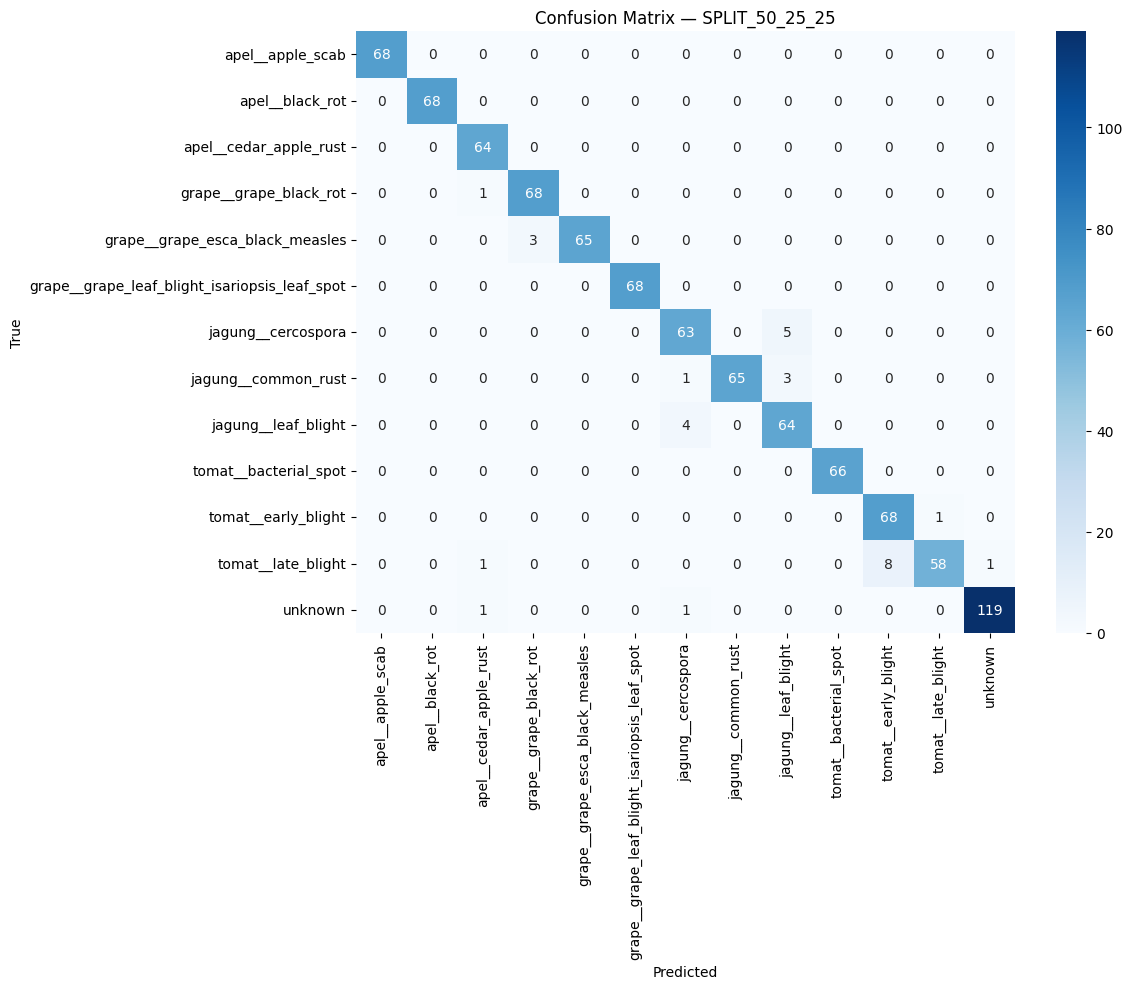

[SPLIT_50_25_25] Tersimpan di /kaggle/working/MODEL_SPLIT_50_25_25

  SPLIT: SPLIT_60_20_20
Jumlah kelas : 13
Train/Val/Test: 2239 / 748 / 748


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                           
--------------------+----------+-------------------------------------------------------------------------------------------
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([13])            
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([13, 2048])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[SPLIT_60_20_20] Epoch 1 train:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 01 | train_loss 1.1318 acc 0.6646 | val_loss 0.3957 acc 0.8543 | lr 1.00e-03


...

Epoch 17 | train_loss 0.0136 acc 0.9951 | val_loss 0.1205 acc 0.9652 | lr 2.50e-04


[SPLIT_60_20_20] Epoch 18 train:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 18 | train_loss 0.0161 acc 0.9960 | val_loss 0.1380 acc 0.9679 | lr 2.50e-04


[SPLIT_60_20_20] Epoch 19 train:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch 19 | train_loss 0.0178 acc 0.9942 | val_loss 0.1256 acc 0.9639 | lr 2.50e-04
  Early stopping di epoch 19 (best val_loss=0.0905)


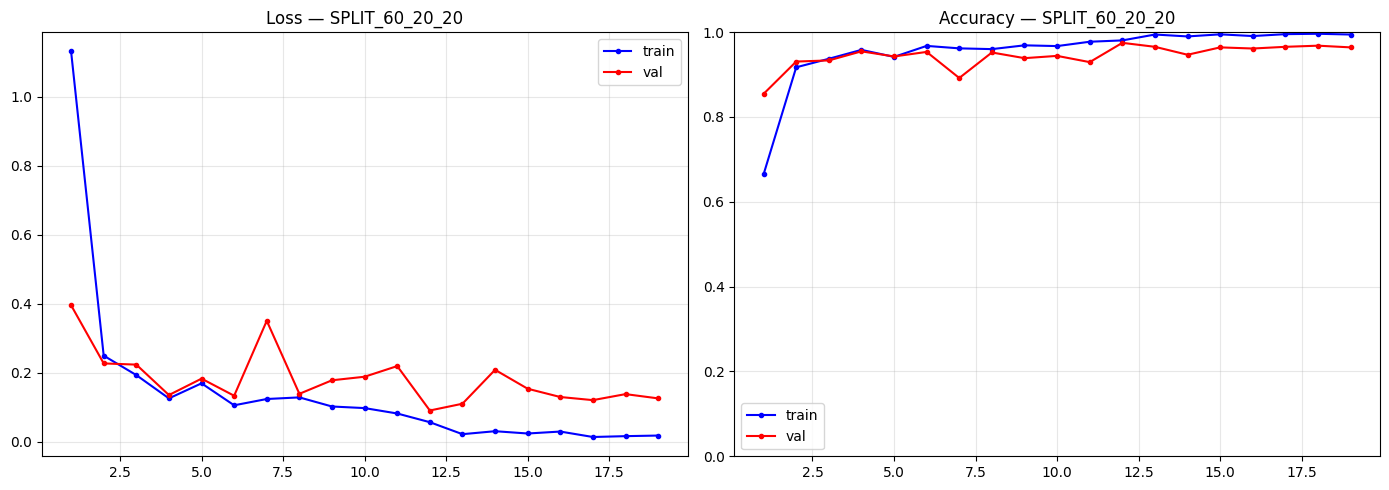

[SPLIT_60_20_20] test:   0%|          | 0/24 [00:00<?, ?it/s]


[SPLIT_60_20_20] TEST  acc 0.9759 | prec 0.9769 | rec 0.9759 | f1 0.9761
                                               precision    recall  f1-score   support

                             apel__apple_scab       1.00      1.00      1.00        54
                              apel__black_rot       1.00      1.00      1.00        55
                       apel__cedar_apple_rust       1.00      0.98      0.99        51
                       grape__grape_black_rot       0.98      1.00      0.99        55
              grape__grape_esca_black_measles       1.00      0.98      0.99        54
grape__grape_leaf_blight_isariopsis_leaf_spot       1.00      1.00      1.00        55
                           jagung__cercospora       0.87      0.96      0.91        55
                          jagung__common_rust       1.00      0.95      0.97        55
                          jagung__leaf_blight       0.92      0.87      0.90        55
                        tomat__bacterial_spot       1.0

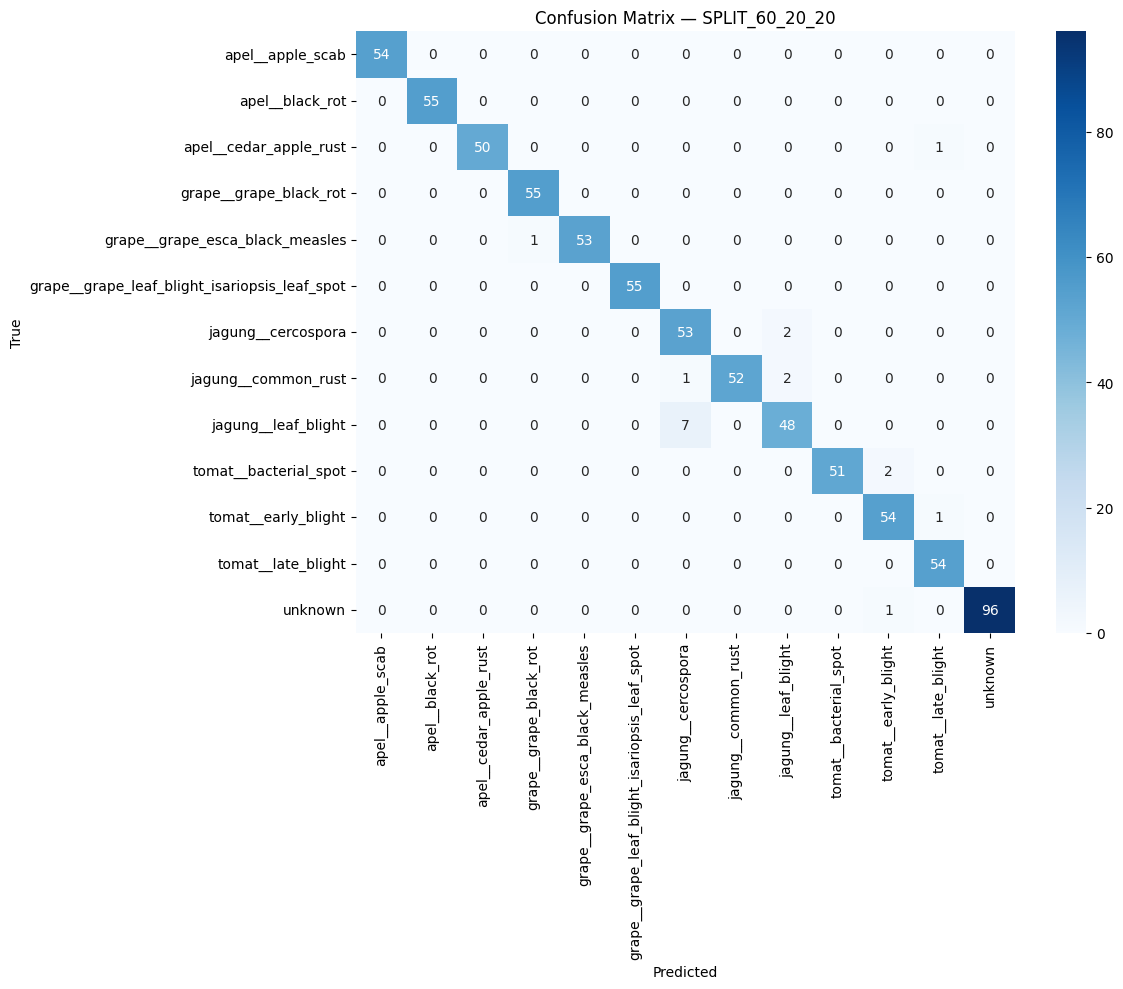

[SPLIT_60_20_20] Tersimpan di /kaggle/working/MODEL_SPLIT_60_20_20

  SPLIT: SPLIT_70_15_15
Jumlah kelas : 13
Train/Val/Test: 2617 / 559 / 559


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                           
--------------------+----------+-------------------------------------------------------------------------------------------
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([13])            
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([13, 2048])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[SPLIT_70_15_15] Epoch 1 train:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 01 | train_loss 1.0123 acc 0.6893 | val_loss 0.3372 acc 0.8837 | lr 1.00e-03


...

Epoch 22 | train_loss 0.0252 acc 0.9939 | val_loss 0.1045 acc 0.9767 | lr 2.50e-04


[SPLIT_70_15_15] Epoch 23 train:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 23 | train_loss 0.0092 acc 0.9977 | val_loss 0.0799 acc 0.9732 | lr 2.50e-04


[SPLIT_70_15_15] Epoch 24 train:   0%|          | 0/82 [00:00<?, ?it/s]

Epoch 24 | train_loss 0.0110 acc 0.9958 | val_loss 0.0788 acc 0.9803 | lr 2.50e-04
  Early stopping di epoch 24 (best val_loss=0.0784)


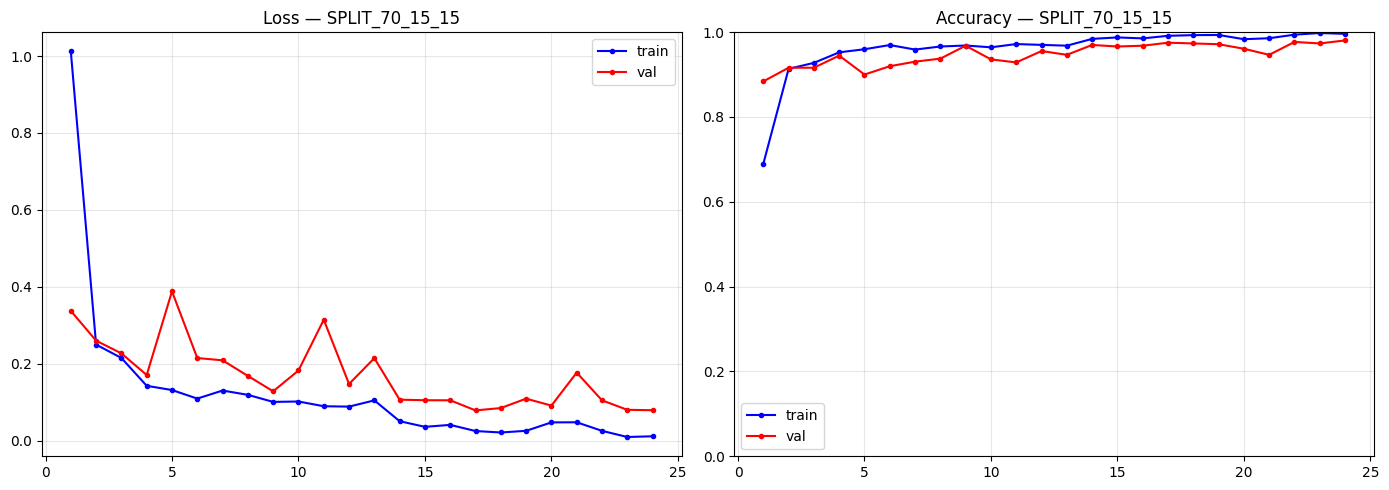

[SPLIT_70_15_15] test:   0%|          | 0/18 [00:00<?, ?it/s]


[SPLIT_70_15_15] TEST  acc 0.9785 | prec 0.9793 | rec 0.9785 | f1 0.9787
                                               precision    recall  f1-score   support

                             apel__apple_scab       1.00      0.97      0.99        40
                              apel__black_rot       1.00      1.00      1.00        41
                       apel__cedar_apple_rust       1.00      1.00      1.00        38
                       grape__grape_black_rot       1.00      0.98      0.99        41
              grape__grape_esca_black_measles       1.00      1.00      1.00        41
grape__grape_leaf_blight_isariopsis_leaf_spot       1.00      1.00      1.00        41
                           jagung__cercospora       0.88      0.93      0.90        41
                          jagung__common_rust       1.00      0.98      0.99        41
                          jagung__leaf_blight       0.93      0.95      0.94        41
                        tomat__bacterial_spot       1.0

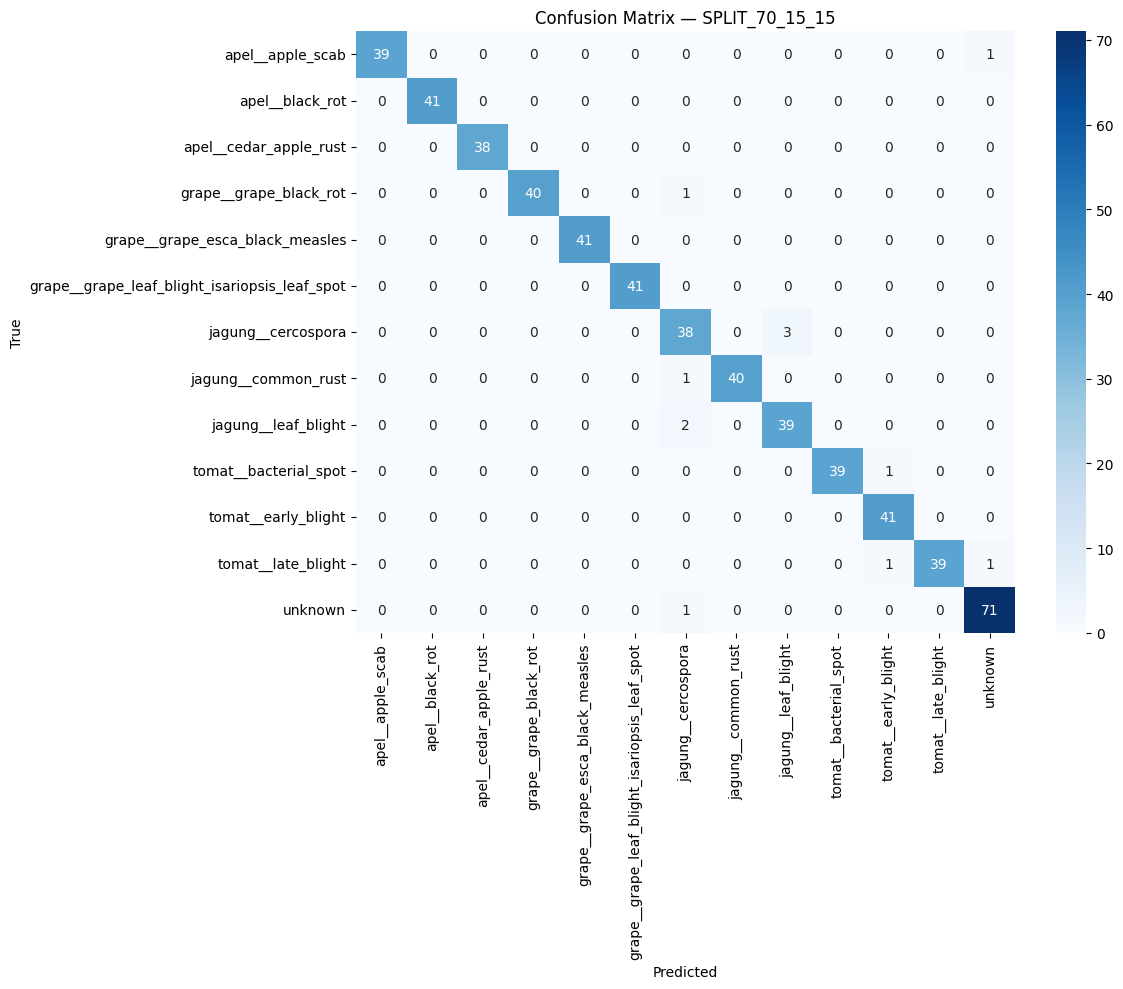

[SPLIT_70_15_15] Tersimpan di /kaggle/working/MODEL_SPLIT_70_15_15

  SPLIT: SPLIT_80_10_10
Jumlah kelas : 13
Train/Val/Test: 2989 / 373 / 373


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

ResNetForImageClassification LOAD REPORT from: microsoft/resnet-50
Key                 | Status   |                                                                                           
--------------------+----------+-------------------------------------------------------------------------------------------
classifier.1.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([13])            
classifier.1.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 2048]) vs model:torch.Size([13, 2048])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


[SPLIT_80_10_10] Epoch 1 train:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 01 | train_loss 0.9696 acc 0.6952 | val_loss 0.3633 acc 0.8660 | lr 1.00e-03


...

Epoch 14 | train_loss 0.0262 acc 0.9933 | val_loss 0.2770 acc 0.9651 | lr 2.50e-04


[SPLIT_80_10_10] Epoch 15 train:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 15 | train_loss 0.0198 acc 0.9933 | val_loss 0.2535 acc 0.9732 | lr 2.50e-04


[SPLIT_80_10_10] Epoch 16 train:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch 16 | train_loss 0.0204 acc 0.9936 | val_loss 0.2725 acc 0.9705 | lr 2.50e-04
  Early stopping di epoch 16 (best val_loss=0.0801)


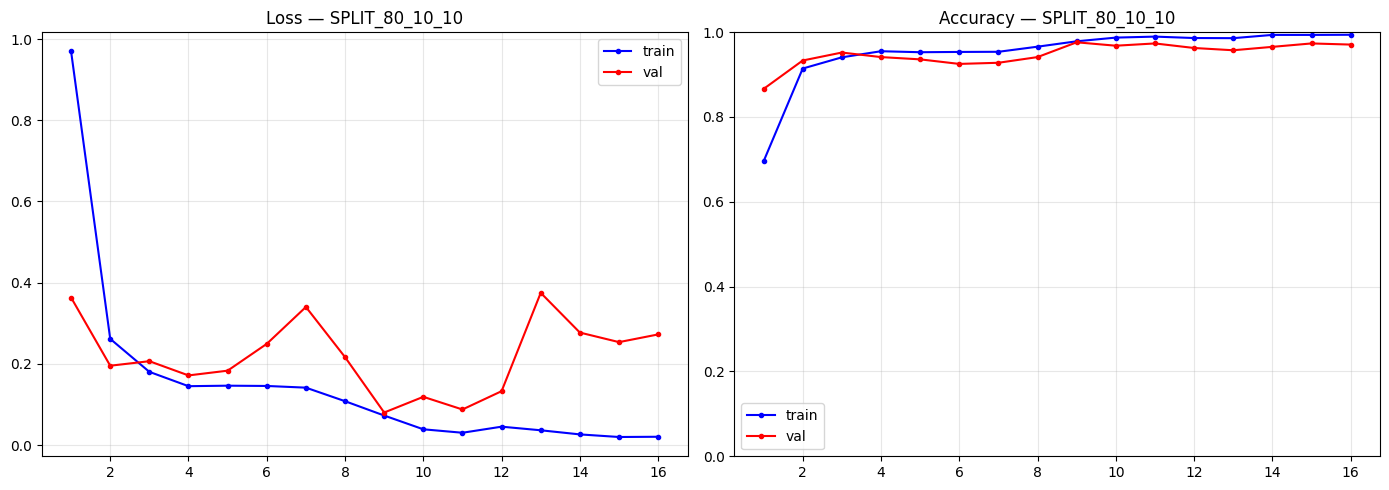

[SPLIT_80_10_10] test:   0%|          | 0/12 [00:00<?, ?it/s]


[SPLIT_80_10_10] TEST  acc 0.9786 | prec 0.9789 | rec 0.9786 | f1 0.9785
                                               precision    recall  f1-score   support

                             apel__apple_scab       1.00      1.00      1.00        27
                              apel__black_rot       0.96      1.00      0.98        27
                       apel__cedar_apple_rust       1.00      0.96      0.98        26
                       grape__grape_black_rot       1.00      1.00      1.00        28
              grape__grape_esca_black_measles       1.00      1.00      1.00        27
grape__grape_leaf_blight_isariopsis_leaf_spot       1.00      1.00      1.00        27
                           jagung__cercospora       0.96      0.93      0.94        27
                          jagung__common_rust       0.97      1.00      0.98        28
                          jagung__leaf_blight       0.93      0.93      0.93        27
                        tomat__bacterial_spot       1.0

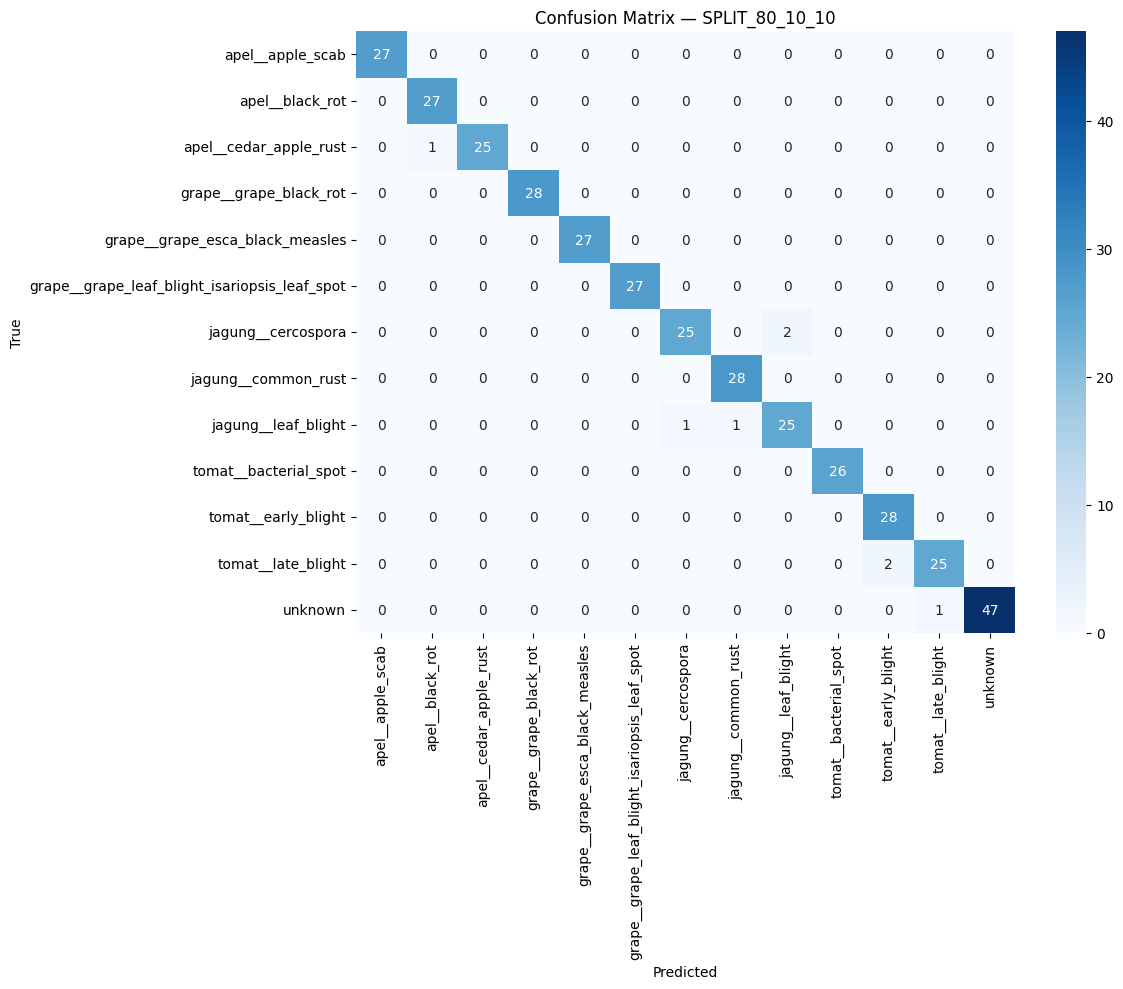

[SPLIT_80_10_10] Tersimpan di /kaggle/working/MODEL_SPLIT_80_10_10

  RINGKASAN SEMUA SPLIT
split                acc      f1  acc+thr  epochs
SPLIT_50_25_25    0.9679  0.9679   0.9625      25
SPLIT_60_20_20    0.9759  0.9761   0.9599      19
SPLIT_70_15_15    0.9785  0.9787   0.9714      24
SPLIT_80_10_10    0.9786  0.9785   0.9705      16

Total waktu: 47.5 menit
Semua model & metrik tersimpan di /kaggle/working/


In [5]:
# Cell 5: loop training semua split
root_by_name={os.path.basename(r):r for r in SPLIT_ROOTS}
all_metrics=[]
t0=time.time()
for name in SPLITS_TO_RUN:
    all_metrics.append(train_one_split(name, root_by_name[name]))

print('\n'+'='*70); print('  RINGKASAN SEMUA SPLIT'); print('='*70)
print(f'{"split":<16}{"acc":>8}{"f1":>8}{"acc+thr":>9}{"epochs":>8}')
for m in all_metrics:
    print(f'{m["split"]:<16}{m["test_accuracy"]:>8.4f}{m["test_f1"]:>8.4f}'
          f'{m["test_accuracy_threshold"]:>9.4f}{m["epochs_trained"]:>8}')
json.dump(all_metrics, open(os.path.join(OUT_ROOT,'ALL_METRICS.json'),'w'), indent=2)
print(f'\nTotal waktu: {(time.time()-t0)/60:.1f} menit')
print('Semua model & metrik tersimpan di /kaggle/working/')

## Cell 6 — Bungkus semua hasil jadi ZIP (untuk diunduh dari Kaggle)
Menghasilkan dua file di `/kaggle/working/`:
- `RESULTS_reports.zip` — **ringan**: semua grafik (`.png`), metrik (`.json`), laporan (`.txt`), confusion matrix (`.csv`). Cepat diunduh.
- `ALL_RESULTS_full.zip` — **lengkap**: termasuk bobot model `.pt` (besar).

Semua isi `/kaggle/working/` juga bisa diunduh langsung lewat tab **Output ▸ Download All** setelah *Commit*.

In [6]:
# Cell 6: bundling hasil -> ZIP
import glob, zipfile, os

def add_to_zip(zip_path, files, arc_base=OUT_ROOT):
    with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as z:
        for f in files:
            if os.path.isfile(f):
                z.write(f, os.path.relpath(f, arc_base))
    return zip_path

all_files=[f for f in glob.glob(os.path.join(OUT_ROOT,'MODEL_*','**','*'), recursive=True) if os.path.isfile(f)]
if os.path.exists(os.path.join(OUT_ROOT,'ALL_METRICS.json')):
    all_files.append(os.path.join(OUT_ROOT,'ALL_METRICS.json'))

light_files=[f for f in all_files if f.lower().endswith(('.png','.json','.txt','.csv'))]
add_to_zip(os.path.join(OUT_ROOT,'RESULTS_reports.zip'),  light_files)
add_to_zip(os.path.join(OUT_ROOT,'ALL_RESULTS_full.zip'), all_files)

print('ZIP dibuat:')
for z in ['RESULTS_reports.zip','ALL_RESULTS_full.zip']:
    p=os.path.join(OUT_ROOT,z)
    print(f'  {os.path.getsize(p)/1e6:8.2f} MB  {z}')

print('\nSemua file output di /kaggle/working/:')
for f in sorted(glob.glob(os.path.join(OUT_ROOT,'**','*'), recursive=True)):
    if os.path.isfile(f):
        print(f'  {os.path.getsize(f)/1e6:8.2f} MB  {os.path.relpath(f,OUT_ROOT)}')

ZIP dibuat:
      0.73 MB  RESULTS_reports.zip
    708.64 MB  ALL_RESULTS_full.zip

Semua file output di /kaggle/working/:
      0.00 MB  ALL_METRICS.json
    708.64 MB  ALL_RESULTS_full.zip
      0.00 MB  MODEL_SPLIT_50_25_25/classification_report.txt
      0.00 MB  MODEL_SPLIT_50_25_25/confusion_matrix.csv
      0.15 MB  MODEL_SPLIT_50_25_25/confusion_matrix.png
      0.00 MB  MODEL_SPLIT_50_25_25/history.json
      0.00 MB  MODEL_SPLIT_50_25_25/metrics.json
     94.49 MB  MODEL_SPLIT_50_25_25/resnet50_best.pt
     94.49 MB  MODEL_SPLIT_50_25_25/resnet50_final.pt
      0.07 MB  MODEL_SPLIT_50_25_25/training_history.png
      0.00 MB  MODEL_SPLIT_60_20_20/classification_report.txt
      0.00 MB  MODEL_SPLIT_60_20_20/confusion_matrix.csv
      0.15 MB  MODEL_SPLIT_60_20_20/confusion_matrix.png
      0.00 MB  MODEL_SPLIT_60_20_20/history.json
      0.00 MB  MODEL_SPLIT_60_20_20/metrics.json
     94.49 MB  MODEL_SPLIT_60_20_20/resnet50_best.pt
     94.49 MB  MODEL_SPLIT_60_20_20/resnet50

## Catatan
- **13 kelas**: `apel__apple_scab, apel__black_rot, apel__cedar_apple_rust, grape__grape_black_rot, grape__grape_esca_black_measles, grape__grape_leaf_blight_isariopsis_leaf_spot, jagung__cercospora, jagung__common_rust, jagung__leaf_blight, tomat__bacterial_spot, tomat__early_blight, tomat__late_blight, unknown`.
- **Pendekatan gabungan**: model 13 kelas (unknown eksplisit) + *threshold* `UNKNOWN_THRESHOLD` saat inferensi. Ubah nilainya (mis. 0.6–0.9) untuk mengatur seberapa ketat model menolak input asing; hasil `acc+thr` di ringkasan membantu memilih nilai terbaik.
- **Output per split** di `/kaggle/working/MODEL_<split>/`: `resnet50_best.pt`, `resnet50_final.pt`, `metrics.json`, `training_history.png`, `confusion_matrix.png`.
- Jika waktu Kaggle terbatas, isi `SPLITS_TO_RUN` dengan sebagian split lalu jalankan bertahap.